In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import json
import torchvision.transforms as transforms
from pathlib import Path
from scipy.interpolate import CloughTocher2DInterpolator
from src import (
    get_singular_values,
    calculate_true_mle,
    get_layer_from_checkpoint,
    run_spectral_analysis,
    get_layer_fingerprint,
    pdf_from_spectrum,
    marcenkoPastur,
    fit_marcenkoPastur,
    level_spacings,
    level_number_variance,
    wignerSurmise,
    wignerSurmise_cdf,
    GaussBroadening,
    GeneralMLP,
)

SWEEP_PATH = Path("mlp_sweep")
HT32_PATH = Path("training_runs/mlp32_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_113516_s0")
GAUSS32_PATH = Path("training_runs/mlp32_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_113641_s0")
HT64_PATH = Path("training_runs/mlp64_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_112717_s0")
GAUSS64_PATH = Path("training_runs/mlp64_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_112842_s0")
HT128_PATH = Path("training_runs/mlp128_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_111642_s0")
GAUSS128_PATH = Path("training_runs/mlp128_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_111809_s0")
HT784_PATH = Path("training_runs/mlp784_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260221_130323_s0")
GAUSS784_PATH = Path("training_runs/mlp784_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260221_130451_s0")

RUN_PATH = Path("rich_learning_test/HT_alpha_1.2/GeneralMLP_LR0.001_BS1024_20260308_181319_s0")

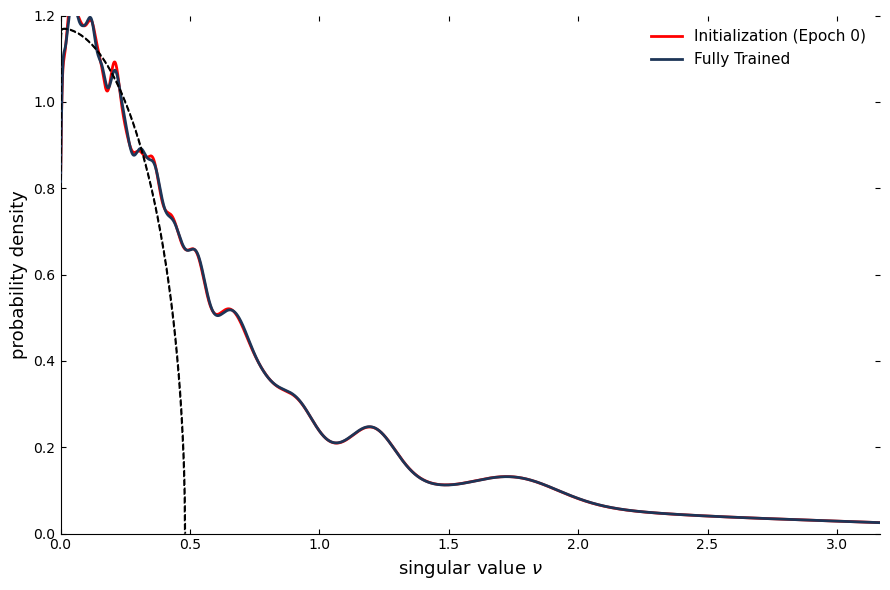

In [20]:
# 1. Initialization and Data Extraction

LAYER_KEY = 'features.2.weight'
W_final = get_layer_from_checkpoint(RUN_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(RUN_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)

nu_final = get_singular_values(W_final)
nu_init  = get_singular_values(W_init)

# Use the official adaptive Broadener from source code

broadener = GaussBroadening(winSize=15, method='replicate')

fig, ax = plt.subplots(figsize=(9, 6))

# Determine global x-limit based on the maximum singular value found in training

x_limit = np.max(nu_final) * 1.2

data_configs = [
(nu_init, 'Initialization (Epoch 0)', 'red'),
(nu_final, 'Fully Trained', '#1d3557') # Dark blue matching paper Fig 1
]

for nu, label, color in data_configs:
    # A. EMPIRICAL DENSITY (Solid Line)
    # Generate high-resolution x and pdf using the official iterative sampler
    x_emp, pdf_emp = pdf_from_spectrum(nu, nSamples=20, broadener=broadener)

    # Mask to ensure it only plots within the viewport
    mask = (x_emp >= 0) & (x_emp <= x_limit)
    ax.plot(x_emp[mask], pdf_emp[mask], color=color, lw=2, label=label, zorder=4)

    # B. RMT THEORY FIT (Dashed Line)
    # [cite_start]This uses the authors' logic to fit ONLY the random bulk [cite: 2427, 2429]
    # range_of_y_to_fit=0.7 prevents the tail from stretching the bulk fit
    a_fit, nuMin_fit, nuMax_fit, _ = fit_marcenkoPastur(nu, broadener, range_of_y_to_fit=0.7)

    # [cite_start]Evaluate theory curve within its specific theoretical support [cite: 2381, 2386]
    x_bulk = np.linspace(nuMin_fit, nuMax_fit, 400)
    y_bulk = marcenkoPastur(x_bulk, a_fit, nuMax_fit, nuMin_fit)

    ax.plot(x_bulk, y_bulk, color='black', linestyle='--', lw=1.2, zorder=5)

    # 2. Physical Review E Aesthetics (Matching Figure 1)

    ax.set_yscale('linear')
    ax.set_ylim(0, 1.2)
    ax.set_xlim(0, x_limit * 0.05)

    ax.set_xlabel(r'singular value $\nu$', fontsize=13)
    ax.set_ylabel('probability density', fontsize=13)

# Professional scientific formatting

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

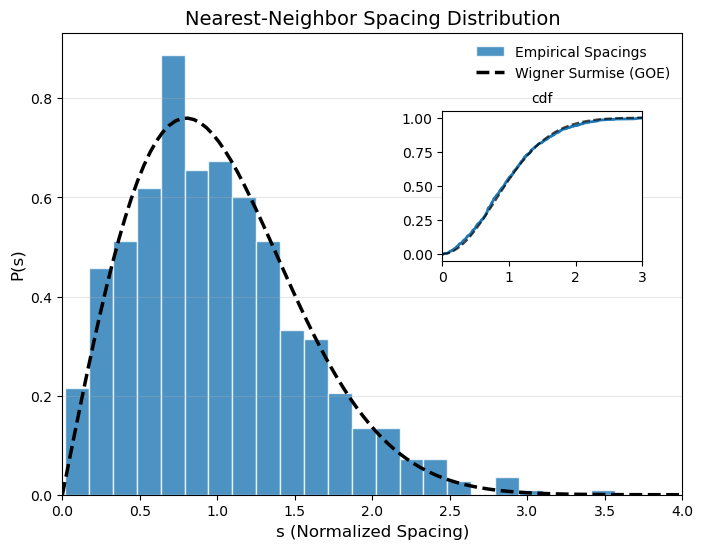

In [21]:
def plot_wigner_recreation(weight_matrix, win_size=15):
    """
    Recreates the nearest-neighbor spacing distribution plot.
    """
    # 1. Prepare data (Cite: 709, 859)
    if isinstance(weight_matrix, torch.Tensor):
        svals = torch.linalg.svdvals(weight_matrix.float()).detach().cpu().numpy()
    else:
        svals = np.linalg.svd(weight_matrix, compute_uv=False)

    svals = np.sort(svals) # (Cite: 709)

    # 2. Unfolding via Gaussian Broadening (Cite: 860, 863)
    # The paper uses a window size of 15 (Cite: 754)
    broadener = GaussBroadening(winSize=win_size, method='replicate')

    # level_spacings internally calls unfold_spectrum using the broadener (Cite: 862)
    spacings = level_spacings(svals, broadener)

    # 3. Visualization (Cite: 766, 940)
    plt.figure(figsize=(8, 6))

    # Empirical Spacing Histogram
    plt.hist(spacings, bins=30, density=True, color='#1f77b4', alpha=0.8,
             edgecolor='white', label='Empirical Spacings')

    # Wigner Surmise Theory Curve (Cite: 768, 868)
    s_theory = np.linspace(0, 4, 100)
    plt.plot(s_theory, wignerSurmise(s_theory), 'k--', lw=2.5, label='Wigner Surmise (GOE)')

    plt.title("Nearest-Neighbor Spacing Distribution", fontsize=14)
    plt.xlabel("s (Normalized Spacing)", fontsize=12)
    plt.ylabel("P(s)", fontsize=12)
    plt.legend(frameon=False)
    plt.xlim(0, 4)
    plt.grid(axis='y', alpha=0.3)

    # 4. Inset for Cumulative Distribution (Cite: 767, 941)
    ax_inset = plt.axes([0.6, 0.5, 0.25, 0.25])
    sorted_s = np.sort(spacings)
    y_cdf = np.arange(len(sorted_s)) / len(sorted_s)
    ax_inset.plot(sorted_s, y_cdf, color='#1f77b4', lw=2)
    ax_inset.plot(s_theory, wignerSurmise_cdf(s_theory), 'k--', alpha=0.7)
    ax_inset.set_title("cdf", fontsize=10)
    ax_inset.set_xlim(0, 3)

    plt.show()

# Usage Example:
LAYER_KEY = 'features.2.weight'
W_final = get_layer_from_checkpoint(RUN_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(RUN_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)
plot_wigner_recreation(W_final)

xi_min= 18.967156370314335  xi_max= 740.3096856364227  n= 724
xi_min= 18.66947492395622  xi_max= 740.3677639032059  n= 724


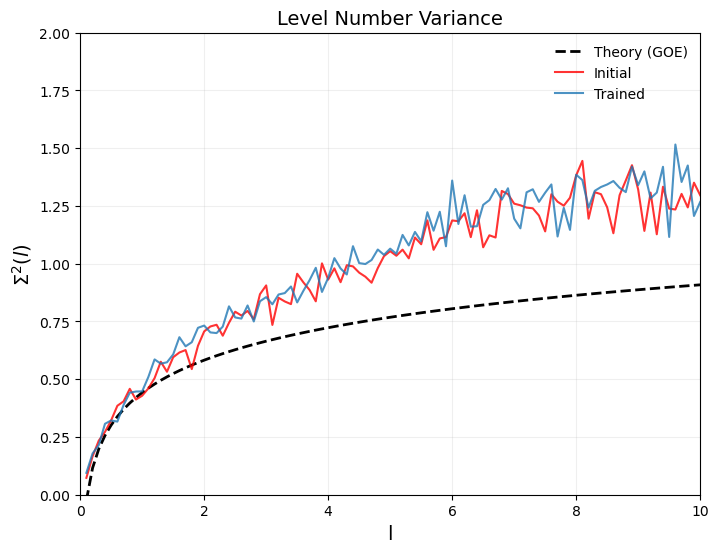

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_dual_level_variance(w_init, w_final, win_size=15):
    """
    Recreates Fig 3: Level number variance comparing initial (red)
    and trained (blue) weights.
    """
    # 1. Extract and sort singular values (Cite: 709, 860)
    s_init = np.sort(get_singular_values(w_init))
    s_final = np.sort(get_singular_values(w_final))

    # 2. Setup Broadener and Parameters (Cite: 754, 758)
    broadener = GaussBroadening(winSize=win_size, method='replicate')
    L_range = np.linspace(0.1, 10, 100) # (Cite: 777)
    opts = {'tol': 0.01, 'maxIterations': 1000, 'minIterations': 100}

    # 3. Compute empirical variance for both (Cite: 774, 775)
    _, sigma_init = level_number_variance(s_init, broadener, L_range, **opts)
    _, sigma_final = level_number_variance(s_final, broadener, L_range, **opts)

    # 4. Theoretical GOE Prediction (Cite: 777, 959)
    gamma = np.euler_gamma
    sigma_goe = (2 / np.pi**2) * (np.log(2 * np.pi * L_range) + gamma + 1 - (np.pi**2 / 8))

    # 5. Visualization (Matches Fig 3/7 colors) (Cite: 810, 995)
    plt.figure(figsize=(8, 6))

    # GOE Theory - Black Dashed (Cite: 811)
    plt.plot(L_range, sigma_goe, 'k--', lw=2, label='Theory (GOE)')

    # Initial - Red (Cite: 779, 810)
    plt.plot(L_range, sigma_init, color='red', lw=1.5, alpha=0.8, label='Initial')

    # Trained - Blue (Cite: 779, 810)
    plt.plot(L_range, sigma_final, color='#1f77b4', lw=1.5, alpha=0.8, label='Trained')

    plt.xlabel('l', fontsize=14)
    plt.ylabel(r'$\Sigma^2(l)$', fontsize=14)
    plt.title(f'Level Number Variance', fontsize=14)
    plt.xlim(0, 10)
    plt.ylim(0, 2.0)
    plt.legend(frameon=False)
    plt.grid(alpha=0.2)
    plt.show()

# Example Usage:
LAYER_KEY = 'features.2.weight'
W_final = get_layer_from_checkpoint(RUN_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(RUN_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)
plot_dual_level_variance(W_init, W_final, win_size=15)

<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:87: SyntaxWarning: invalid escape sequence '\l'
<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:87: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_155652/4075298011.py:83: SyntaxWarning: invalid escape sequence '\l'
  plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Criticality ($\lambda=0$)')
/tmp/ipykernel_155652/4075298011.py:87: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Maximal Lyapunov Exponent ($\lambda$)", fontsize=11)


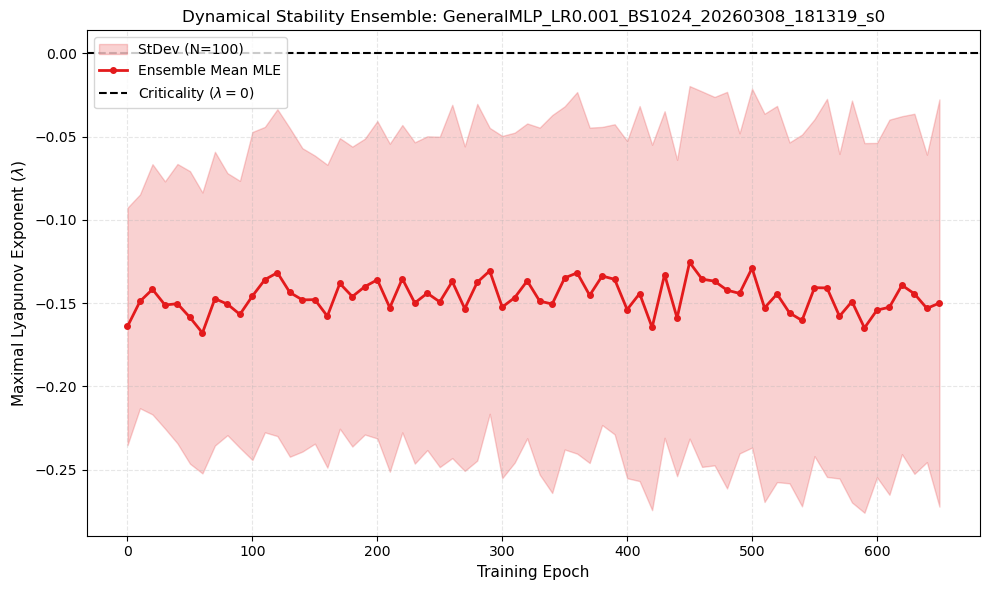

In [4]:
def get_full_weight_chain(checkpoint_path, layer_names=None):
    """
    Loads a checkpoint and returns weights in the SPECIFIC order of the forward pass.
    """
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    state_dict = ckpt.get('model_state', ckpt)

    # If you know your layer names, list them here in order!
    # Example for a common CIFAR MLP:
    if layer_names is None:
        # Fallback: try to filter and sort, but print the order so you can verify
        keys = sorted([k for k in state_dict.keys() if 'weight' in k and 'bn' not in k.lower()],
                      key=lambda x: [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', x)])
    else:
        keys = layer_names

    # print(f"  -> Building chain from keys: {keys}")
    return [state_dict[k].float() for k in keys]

def plot_lyapunov_evolution(run_dir, activation='relu', input_dim=784,
                                     layer_names=None, num_samples=20):
    """
    Analyzes checkpoints and plots the Mean MLE with a Standard Deviation shaded region.

    Args:
        num_samples: Number of times to run the MLE per checkpoint (the 'X' times).
    """
    checkpoint_dir = Path(run_dir) / "checkpoints"
    if not checkpoint_dir.exists():
        checkpoint_dir = Path(run_dir)

    checkpoint_files = list(checkpoint_dir.glob("weights_epoch_*.pth"))
    if not checkpoint_files:
        checkpoint_files = list(checkpoint_dir.glob("*.pth"))

    def extract_epoch(f):
        nums = re.findall(r'\d+', f.name)
        return int(nums[-1]) if nums else 0

    checkpoint_files.sort(key=extract_epoch)

    epochs = []
    mle_means = []
    mle_stds = []

    # print(f"Processing {len(checkpoint_files)} checkpoints (Ensemble size: {num_samples})...")

    for f in checkpoint_files:
        # Load weights once for the checkpoint
        weights = get_full_weight_chain(f, layer_names=layer_names)
        if not weights: continue

        # Run the calculation X times to account for stochasticity
        batch_mles = []
        for _ in range(num_samples):
            # Generate a new random input sample for each iteration
            sample_input = torch.randn(1, input_dim)
            mle = calculate_true_mle(weights, sample_input, activation=activation)
            batch_mles.append(mle)

        epochs.append(extract_epoch(f))
        mle_means.append(np.mean(batch_mles))
        mle_stds.append(np.std(batch_mles))

        # print(f"  Epoch {epochs[-1]:3d} | Mean MLE: {mle_means[-1]:.4f} +/- {mle_stds[-1]:.4f}")

    # Convert to numpy arrays for plotting
    epochs = np.array(epochs)
    means = np.array(mle_means)
    stds = np.array(mle_stds)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))

    # Plot the shaded Standard Deviation region
    plt.fill_between(epochs, means - stds, means + stds,
                     color='#e31a1c', alpha=0.2, label=f'StDev (N={num_samples})')

    # Plot the Mean line
    plt.plot(epochs, means, 'o-', color='#e31a1c', markersize=4, linewidth=2, label='Ensemble Mean MLE')

    # Criticality Reference
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Criticality ($\lambda=0$)')

    plt.title(f"Dynamical Stability Ensemble: {Path(run_dir).name}", fontsize=12)
    plt.xlabel("Training Epoch", fontsize=11)
    plt.ylabel("Maximal Lyapunov Exponent ($\lambda$)", fontsize=11)
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---
CIFAR_LAYERS = [
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    'features.6.weight',
    'features.8.weight',
    'features.10.weight',
    'features.12.weight',
    'features.14.weight',
    'features.16.weight',
    'classifier.weight'
]
plot_lyapunov_evolution(RUN_PATH, activation='tanh', input_dim=784, layer_names=CIFAR_LAYERS, num_samples=100)

Epoch 0 | q_start: 0.7141 | q_end: 0.7474
Epoch 10 | q_start: 0.7141 | q_end: 2.9781
Epoch 20 | q_start: 0.7141 | q_end: 3.3314
Epoch 30 | q_start: 0.7141 | q_end: 3.5486
Epoch 40 | q_start: 0.7141 | q_end: 3.7018
Epoch 50 | q_start: 0.7141 | q_end: 3.8409
Epoch 60 | q_start: 0.7141 | q_end: 3.9636
Epoch 70 | q_start: 0.7141 | q_end: 4.0720
Epoch 80 | q_start: 0.7141 | q_end: 4.1597
Epoch 90 | q_start: 0.7141 | q_end: 4.2573
Epoch 100 | q_start: 0.7141 | q_end: 4.3478
Epoch 110 | q_start: 0.7141 | q_end: 4.4350
Epoch 120 | q_start: 0.7141 | q_end: 4.4939
Epoch 130 | q_start: 0.7141 | q_end: 4.5738
Epoch 140 | q_start: 0.7141 | q_end: 4.6294
Epoch 150 | q_start: 0.7141 | q_end: 4.6995
Epoch 160 | q_start: 0.7141 | q_end: 4.7590
Epoch 170 | q_start: 0.7141 | q_end: 4.8101
Epoch 180 | q_start: 0.7141 | q_end: 4.8552
Epoch 190 | q_start: 0.7141 | q_end: 4.9113
Epoch 200 | q_start: 0.7141 | q_end: 4.9563
Epoch 210 | q_start: 0.7141 | q_end: 4.9971
Epoch 220 | q_start: 0.7141 | q_end: 5.0425

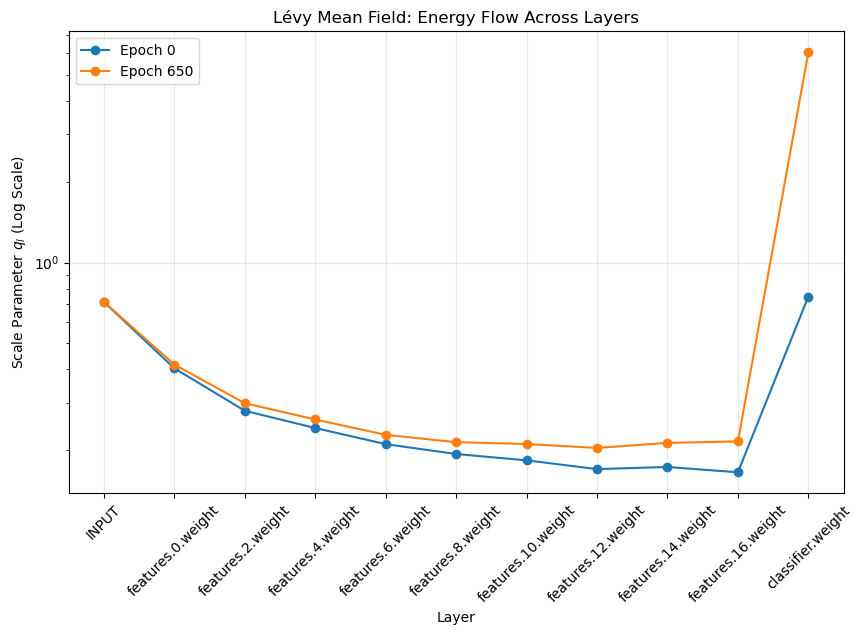

In [10]:
from torchvision.datasets import CIFAR10, MNIST
from torch.utils.data import DataLoader
import torch.nn as nn

def calculate_empirical_ql_flow(run_dir, alpha=1.2, device='cpu'):
    """
    Calculates the empirical scale parameter q_l across all layers and checkpoints
    strictly following the alpha-moment definition in the Qu et al. manuscript.
    """
    run_path = Path(run_dir)
    with open(run_path / "run_config.json", "r") as f:
        config = json.load(f)

    # 1. Data Setup (To get the input x0)
    data_cfg = config['data_config']
    norm_mean = data_cfg['transforms'][1]['Normalize']['mean']
    norm_std = data_cfg['transforms'][1]['Normalize']['std']

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std)
    ])

    ds_class = CIFAR10 if data_cfg['dataset_name'] == 'CIFAR10' else MNIST
    dataset = ds_class(root='./data', train=False, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=data_cfg['batch_size'], shuffle=True)

    # Get initial input x0
    x, _ = next(iter(loader))
    x = x.to(device).view(x.size(0), -1)

    # 2. Model Reconstruction
    model_params = config['model_params']['kwargs']
    # Extract Dw/Db if parameterized in your init, else we treat the weights as-is
    model = GeneralMLP(**model_params).to(device)
    activation_fn = nn.ReLU() if model_params['activation_name'] == 'relu' else nn.Tanh()

    checkpoint_dir = run_path / "checkpoints"
    ckpt_files = sorted(list(checkpoint_dir.glob("weights_epoch_*.pth")),
                        key=lambda x: int(x.stem.split('_')[-1]))

    results = {} # Epoch -> List of q_l values

    for ckpt_p in ckpt_files:
        epoch = int(ckpt_p.stem.split('_')[-1])
        state = torch.load(ckpt_p, map_location=device)
        model.load_state_dict(state.get('model_state', state))
        model.eval()

        # q0: The starting energy of the input data
        # Equation: q0 = (1/N) * sum(|x0|^alpha)
        q_flow = [torch.mean(torch.abs(x)**alpha).item()]

        curr_act = x
        with torch.no_grad():
            # Propagate through the 'features' Sequential block
            for layer in model.features:
                if isinstance(layer, nn.Linear):
                    # Linear transformation: h = Wx + b
                    h = layer(curr_act)
                    # Non-linear activation: x_next = phi(h)
                    curr_act = activation_fn(h)

                    # Calculate empirical q_l for this layer
                    # Strictly: q_l = mean(|phi(h)|^alpha)
                    q_l = torch.mean(torch.abs(curr_act)**alpha).item()
                    q_flow.append(q_l)

            # Final Classifier Layer
            h_final = model.classifier(curr_act)
            # The paper usually stops at the last hidden layer, but we include it for completeness
            q_final = torch.mean(torch.abs(h_final)**alpha).item()
            q_flow.append(q_final)

        results[epoch] = q_flow
        print(f"Epoch {epoch} | q_start: {q_flow[0]:.4f} | q_end: {q_flow[-1]:.4f}")

    return results

# --- 4. PLOTTING THE "ENERGY FLOW" ---

def plot_energy_flow(results, layer_names):
    plt.figure(figsize=(10, 6))

    # Plot first, middle, and last epoch to see the evolution
    epochs_to_show = [min(results.keys()), max(results.keys()) // 2, max(results.keys())]

    for epoch in epochs_to_show:
        if epoch in results:
            plt.plot(range(len(layer_names)), results[epoch], 'o-', label=f'Epoch {epoch}')

    plt.xticks(range(len(layer_names)), layer_names, rotation=45)
    plt.yscale('log') # Scale parameters often vary by orders of magnitude
    plt.ylabel("Scale Parameter $q_l$ (Log Scale)")
    plt.xlabel("Layer")
    plt.title("Lévy Mean Field: Energy Flow Across Layers")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

LAYERS = [
    'INPUT',
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    'features.6.weight',
    'features.8.weight',
    'features.10.weight',
    'features.12.weight',
    'features.14.weight',
    'features.16.weight',
    'classifier.weight'
]
results = calculate_empirical_ql_flow(RUN_PATH, alpha=1.2, device='cuda')
plot_energy_flow(results, LAYERS)

In [ ]:
def plot_sweep_heatmap(data_source, metric='test_acc', stat='mean', layer_name=None, vmin=None, vmax=None):
    """
    Generates a high-fidelity interpolated phase diagram with manual color scaling.
    """
    # 1. Load Data
    if isinstance(data_source, (str, Path)):
        df = pd.read_csv(data_source)
    else:
        df = data_source

    # 2. Metric Resolution
    target_col = f"{metric}_{stat}"
    if target_col not in df.columns:
        print(f"Error: Column {target_col} not found.")
        return

    # 3. Filtering
    if layer_name and 'layer' in df.columns:
        sub_df = df[df['layer'] == layer_name].copy()
    else:
        sub_df = df.copy()

    sub_df = sub_df.dropna(subset=[target_col])

    alphas = sub_df['alpha'].values
    gs = sub_df['g'].values
    values = sub_df[target_col].values

    # 4. Interpolation
    points = np.column_stack((alphas, gs))
    interp_func = CloughTocher2DInterpolator(points, values)

    a_grid = np.linspace(alphas.min(), alphas.max(), 300)
    g_grid = np.linspace(gs.min(), gs.max(), 300)
    A, G = np.meshgrid(a_grid, g_grid)
    Z = interp_func(A, G)

    # 5. Rendering
    plt.figure(figsize=(10, 8), dpi=120)

    if stat in ['sem', 'pct_err']:
        cmap = 'Reds'
    else:
        cmap = 'magma'

    # Set dynamic or manual limits
    # vmin/vmax force the gradient to spread across your chosen range
    vmin = vmin if vmin is not None else np.nanmin(Z)
    vmax = vmax if vmax is not None else np.nanmax(Z)

    # Use extend='both' to handle values outside the vmin/vmax window
    cp = plt.contourf(A, G, Z, levels=100, cmap=cmap, vmin=vmin, vmax=vmax, extend='both')

    cbar = plt.colorbar(cp)
    cbar.set_label(f"{metric.replace('_', ' ').upper()} {stat.upper()}", fontsize=12)

    plt.scatter(alphas, gs, c='white', s=15, edgecolors='black',
                linewidths=0.5, alpha=0.4, label='Sampling Points')

    # Labeling
    title_suffix = f" | {layer_name}" if layer_name else ""
    plt.title(f"Performance Phase Map: {metric.upper()} {stat.upper()}{title_suffix}",
              fontsize=14, pad=20)
    plt.xlabel(r"Heavy-Tail Stability ($\alpha$)", fontsize=12)
    plt.ylabel(r"Variance Scaling ($g$)", fontsize=12)

    plt.tight_layout()
    plt.show()

# --- Example: Zooming in on the 0.90 to 0.98 accuracy range ---
PERF_PATH = "sweep_master_results_perf_summary.csv"
plot_sweep_heatmap(PERF_PATH, metric='test_acc', stat='mean', vmin=0.90, vmax=0.98)

In [ ]:
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']
EPOCHS = range(0, 160, 10)

def get_layer_rotations(run_dir, layers, epochs):
    """Calculates cosine similarity between the top singular vector at epoch 0 vs. t."""
    results = {layer: [] for layer in layers}

    for layer in layers:
        # Load Reference State (Epoch 0) using strict analysis tools
        W0 = get_layer_from_checkpoint(run_dir / "checkpoints/weights_epoch_0.pth", layer)
        _, _, Vt0 = torch.svd(W0)
        v0 = Vt0[:, 0] # Principal right-singular vector

        for epoch in epochs:
            ckpt_path = run_dir / "checkpoints" / f"weights_epoch_{epoch}.pth"
            if not ckpt_path.exists():
                results[layer].append(None)
                continue

            # Load Target State
            Wt = get_layer_from_checkpoint(ckpt_path, layer)
            _, _, Vtt = torch.svd(Wt)
            vt = Vtt[:, 0]

            # Cosine Similarity (absolute value to ignore phase flips)
            similarity = torch.abs(torch.dot(v0, vt)).item()
            results[layer].append(similarity)

    return results

# 2. Execution
ht_rotations = get_layer_rotations(HT32_PATH, LAYERS, EPOCHS)
ga_rotations = get_layer_rotations(GAUSS32_PATH, LAYERS, EPOCHS)

# 3. Visualization Suite
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
run_styles = [
    (ht_rotations, '#1f77b4', 'o', 'HT (α=1.2)'),
    (ga_rotations, '#d62728', 's', 'Gaussian (α=2.0)')
]

for i, layer in enumerate(LAYERS):
    ax = axes[i]
    for results, color, marker, label in run_styles:
        ax.plot(EPOCHS, results[layer], color=color, marker=marker,
                label=f"{label} {layer}", markersize=4, alpha=0.8)

    ax.axhline(1.0, color='black', alpha=0.2, linestyle='--')
    ax.set_title(f"Layer: {layer}", fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.grid(True, which='both', alpha=0.1)

    if i == 0:
        ax.set_ylabel("Top Eigenvector Cosine Similarity")
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Paths & Configuration
# Assuming master config is two levels up from the run leaf
CONFIG_PATH = HT784_PATH.parent.parent / "mlp784_mnist.yaml"
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']
K_VALUES = list(range(0, 11))

# 2. Execution and Plotting Loop
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, layer in enumerate(LAYERS):
    ax = axes[i]
    print(f"Executing sweep for {layer}...")

    # Automated parent wrapper handles data loading and model factory
    ht_raw = run_spectral_analysis(HT784_PATH, CONFIG_PATH, layer, K_VALUES, mode='ablate')
    ga_raw = run_spectral_analysis(GAUSS784_PATH, CONFIG_PATH, layer, K_VALUES, mode='ablate')

    # Extract accuracies from the result dictionaries
    ht_accs = [r['accuracy'] for r in ht_raw]
    ga_accs = [r['accuracy'] for r in ga_raw]

    # Visualization
    ax.plot(K_VALUES, ht_accs, 'b-o', label='HT (Lévy α=1.2)', linewidth=2)
    ax.plot(K_VALUES, ga_accs, 'r-s', label='Gaussian (α=2.0)', linewidth=2)

    # Formatting
    ax.axhline(0.1, color='black', linestyle='--', alpha=0.3, label='Chance')
    ax.set_title(f"Ablation: {layer}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Top-K Singular Values Removed", fontsize=11)
    ax.grid(True, which='both', alpha=0.1)

    if i == 0:
        ax.set_ylabel("Validation Accuracy", fontsize=11)
    if i == 2:
        ax.legend(frameon=True, loc='lower left', fontsize='small')

plt.suptitle("Spectral Sensitivity Across Architecture Depth", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def analyze_run(run_path, layers):
    """
    Analyzes a training run by comparing the final state to initialization
    using standardized fingerprinting.
    """
    results = []

    # Checkpoints for comparison to calculate displacement and stability
    init_path = run_path / "checkpoints" / "weights_epoch_0.pth"
    final_path = run_path / "final_model.pth"

    for layer in layers:
        # Strict usage of analysis utilities
        W_init = get_layer_from_checkpoint(init_path, layer)
        W_final = get_layer_from_checkpoint(final_path, layer)

        # Computes IPR, Eff Rank, Displacement, and PR in one pass
        metrics = get_layer_fingerprint(W_init, W_final)
        metrics['layer'] = layer
        results.append(metrics)

    return pd.DataFrame(results)

# 1. Config Paths
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']

# 2. Execution
ht_df = analyze_run(HT784_PATH, LAYERS)
ga_df = analyze_run(GAUSS784_PATH, LAYERS)

# 3. Output
print("--- Heavy-Tailed (HT) Spectral Fingerprint ---")
print(ht_df[['layer', 'ipr', 'effective_rank', 'displacement', 'participation_ratio', 'hill_alpha', 'spectral_entropy', 'dominance_ratio']])

print("\n--- Gaussian (GA) Spectral Fingerprint ---")
print(ga_df[['layer', 'ipr', 'effective_rank', 'displacement', 'participation_ratio', 'hill_alpha', 'spectral_entropy', 'dominance_ratio']])

In [27]:
def aggregate_sweep_stats(sweep_root, layers, output_name="sweep_master_results.csv"):
    """
    Crawls sweep directory, computes fingerprints, and generates
    summary statistics (Mean, Median, SEM).
    """
    layer_results = []
    perf_results = []
    sweep_root = Path(sweep_root)

    # Define SEM as a proper function so Pandas names the column 'sem'
    def sem(x):
        return x.std() / np.sqrt(len(x)) if len(x) > 0 else np.nan

    # 1. Extraction Loop
    for param_dir in sweep_root.iterdir():
        if not param_dir.is_dir(): continue
        try:
            parts = param_dir.name.split('_')
            alpha, g = float(parts[1]), float(parts[3])
        except (IndexError, ValueError): continue

        for run_path in param_dir.iterdir():
            if not run_path.is_dir(): continue

            # --- Performance Data (Model-wide) ---
            log_path = run_path / "train_log.csv"
            test_acc = np.nan
            if log_path.exists():
                try:
                    log_df = pd.read_csv(log_path)
                    if not log_df.empty:
                        test_acc = log_df.sort_values('epoch').iloc[-1]['test_acc']
                except: pass

            perf_results.append({'alpha': alpha, 'g': g, 'run_name': run_path.name, 'test_acc': test_acc})

            # --- Spectral Data (Layer-specific) ---
            init_path = run_path / "checkpoints" / "weights_epoch_0.pth"
            final_path = run_path / "final_model.pth"
            if not (init_path.exists() and final_path.exists()): continue

            for layer in layers:
                try:
                    W_0 = get_layer_from_checkpoint(init_path, layer)
                    W_T = get_layer_from_checkpoint(final_path, layer)
                    metrics = get_layer_fingerprint(W_0, W_T)
                    metrics.update({'alpha': alpha, 'g': g, 'layer': layer, 'run_name': run_path.name})
                    layer_results.append(metrics)
                except Exception as e: print(f"Error {layer}: {e}")

    # 2. Convert to DataFrames
    ldf = pd.DataFrame(layer_results)
    pdf = pd.DataFrame(perf_results)

    # 3. Aggregate Layer Stats
    spec_cols = ['participation_ratio', 'displacement', 'effective_rank', 'ipr', 'hill_alpha', 'spectral_entropy', 'dominance_ratio']
    spec_summary = ldf.groupby(['alpha', 'g', 'layer'])[spec_cols].agg(['mean', 'median', sem])

    # Flatten MultiIndex safely: ('ipr', 'mean') -> 'ipr_mean'
    spec_summary.columns = [f"{col}_{stat}" for col, stat in spec_summary.columns]
    spec_summary = spec_summary.reset_index()

    # 4. Aggregate Performance Stats (Exactly 1 row per alpha/g)
    perf_summary = pdf.groupby(['alpha', 'g'])['test_acc'].agg(['mean', 'median', sem])
    perf_summary.columns = ['test_acc_mean', 'test_acc_median', 'test_acc_sem']
    perf_summary = perf_summary.reset_index()

    # 5. Add PCT_ERR
    for col in spec_cols:
        spec_summary[f'{col}_pct_err'] = (spec_summary[f'{col}_sem'] / spec_summary[f'{col}_mean'].replace(0, np.nan)) * 100

    perf_summary['test_acc_pct_err'] = (perf_summary['test_acc_sem'] / perf_summary['test_acc_mean'].replace(0, np.nan)) * 100

    # 6. Export
    ldf.to_csv(output_name, index=False)
    spec_summary.to_csv(output_name.replace(".csv", "_spec_summary.csv"), index=False)
    perf_summary.to_csv(output_name.replace(".csv", "_perf_summary.csv"), index=False)

    return spec_summary, perf_summary

# --- Execution ---
# Updated for your proposed 5-layer depth
LAYERS = [
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    'features.6.weight',
    'classifier.weight'
]

master_df = aggregate_sweep_stats(SWEEP_PATH, LAYERS)

In [ ]:
def plot_universality_heatmap(data_source, layer_name, metric='participation_ratio', stat='mean'):
    """
    Produces an interpolated phase map.

    Args:
        data_source (str/Path/pd.DataFrame): The summary stats to visualize.
        layer_name (str): The specific layer (e.g., 'classifier.weight').
        metric (str): The fingerprint metric (e.g., 'participation_ratio').
        stat (str): The statistic type: 'mean', 'median', 'sem', or 'pct_err'.
        smooth (float): Smoothing factor to handle seed-level noise.
    """
    # 1. Robust Data Loading
    if isinstance(data_source, (str, Path)):
        if not Path(data_source).exists():
            print(f"Error: File {data_source} not found.")
            return
        df = pd.read_csv(data_source)
    else:
        df = data_source

    # 2. Dynamic Column Selection
    target_col = f"{metric}_{stat}"
    if target_col not in df.columns:
        available = [c for c in df.columns if metric in c]
        print(f"Error: Column '{target_col}' not found. Available: {available}")
        return

    # 3. Filtering and Prep
    sub_df = df[df['layer'] == layer_name].copy().dropna(subset=[target_col])
    if sub_df.empty:
        print(f"Error: No data found for layer '{layer_name}'.")
        return

    alphas = sub_df['alpha'].values
    gs = sub_df['g'].values
    values = sub_df[target_col].values

    # 4. Clough-Tocher Interpolation
    # This method uses a Delaunay triangulation of quincunx points.
    points = np.column_stack((alphas, gs))
    interp_func = CloughTocher2DInterpolator(points, values)

    # Generate a high-resolution grid for the visual surface
    alpha_grid = np.linspace(alphas.min(), alphas.max(), 200)
    g_grid = np.linspace(gs.min(), gs.max(), 200)
    A, G = np.meshgrid(alpha_grid, g_grid)

    # Compute the interpolated values across the mesh
    # We use a combined array for the query points
    Z = interp_func(A, G)

    # 5. Plotting
    plt.figure(figsize=(9, 7), dpi=120)

    # Use 'magma' for metrics and 'Reds' for instability (SEM/PCT_ERR)
    cmap = 'magma' if stat not in ['sem', 'pct_err'] else 'Reds'

    # Clough-Tocher ensures the transition ridge is a solid vertical band
    cp = plt.contourf(A, G, Z, levels=100, cmap=cmap)

    cbar = plt.colorbar(cp)
    cbar.set_label(f"{metric.replace('_', ' ').title()} ({stat.upper()})", fontsize=11)

    # Overlay the quincunx/grid points
    plt.scatter(alphas, gs, c='white', s=25, edgecolors='black', linewidths=0.8, alpha=0.5, label='Sampling Points')

    plt.title(f"Phase Diagram (Clough-Tocher): {layer_name}\n{metric.upper()} {stat.upper()}", fontsize=14, pad=15)
    plt.xlabel(r"Heavy-Tail Stability ($\alpha$)", fontsize=12)
    plt.ylabel(r"Variance Scaling ($g$)", fontsize=12)

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
SUMMARY_PATH = "sweep_master_results_spec_summary.csv"
plot_universality_heatmap(SUMMARY_PATH, 'features.2.weight', metric='effective_rank', stat='pct_err')

In [ ]:
def plot_phase_slice(data_source, layer_name, slice_axis='alpha', fixed_val=1.8, metric='effective_rank_pct_err'):
    """
    Cuts a 1D slice through the phase diagram.

    Args:
        slice_axis (str): 'alpha' to slice at a fixed alpha (Vertical),
                         'g' to slice at a fixed g (Horizontal).
        fixed_val (float): The coordinate to lock (e.g., 1.8 for the ridge).
    """
    df = pd.read_csv(data_source) if isinstance(data_source, str) else data_source

    # 1. Filter for Layer
    sub = df[df['layer'] == layer_name].copy()

    # 2. Identify the Slice
    # We use a small epsilon for float comparison to catch our grid points
    if slice_axis == 'alpha':
        slice_df = sub[np.isclose(sub['alpha'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'g', r"Variance Scaling ($g$)"
        title = f"Vertical Slice at $\\alpha={fixed_val}$"
    else:
        slice_df = sub[np.isclose(sub['g'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'alpha', r"Heavy-Tail Stability ($\alpha$)"
        title = f"Horizontal Slice at $g={fixed_val}$"

    if slice_df.empty:
        print(f"Error: No data found at {slice_axis}={fixed_val}. Check your grid values.")
        return

    # 3. Sort for a clean line plot
    slice_df = slice_df.sort_values(x_col)

    # 4. Plotting
    plt.figure(figsize=(10, 5), dpi=100)

    # 1. Tighten the Y-axis to the data range
    # This forces the plot to show the subtle 'Resonance Peaks'
    plt.ylim(slice_df[metric].min() - 0.5, slice_df[metric].max() + 0.5)

    # 2. Add high-precision markers
    plt.plot(slice_df[x_col], slice_df[metric], marker='D', markersize=6)

    # We plot the pct_err directly to see the "resonance" peaks
    plt.plot(slice_df[x_col], slice_df[metric], marker='o', linestyle='-',
             linewidth=2, color='#8B0000', label=metric.upper())

    plt.fill_between(slice_df[x_col], 0, slice_df[metric], alpha=0.1, color='red')

    plt.title(f"{title}: {layer_name}\nMetric: {metric.replace('_', ' ').upper()}", fontsize=13)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Relative Volatility (%)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_performance_slice(data_source, slice_axis='alpha', fixed_val=1.9, metric='test_acc_mean'):
    """
    Slices the global performance data (Accuracy) independently of layers.
    """
    df = pd.read_csv(data_source) if isinstance(data_source, str) else data_source

    # Identify the Slice
    if slice_axis == 'alpha':
        slice_df = df[np.isclose(df['alpha'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'g', r"Variance Scaling ($g$)"
    else:
        slice_df = df[np.isclose(df['g'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'alpha', r"Heavy-Tail Stability ($\alpha$)"

    slice_df = slice_df.sort_values(x_col)

    # Plotting
    plt.figure(figsize=(10, 5), dpi=100)

    plt.plot(slice_df[x_col], slice_df[metric], marker='s', linestyle='-',
             linewidth=2, color='#00008B', label=metric.upper())

    plt.title(f"Performance Slice at {slice_axis}={fixed_val}\nMetric: {metric.upper()}", fontsize=13)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Test Accuracy", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
plot_performance_slice("sweep_master_results_perf_summary.csv",
                       slice_axis='alpha',
                       fixed_val=1.9,
                       metric='test_acc_pct_err')

# --- Example Usage for the Ridge ---
plot_phase_slice("sweep_master_results_spec_summary.csv",
                 layer_name="features.0.weight",
                 slice_axis='alpha',
                 fixed_val=1.9,
                 metric='effective_rank_pct_err')

In [ ]:
def plot_alpha_depth_profile(data_source, target_g, alpha_list=[1.0, 1.2, 1.4, 1.6, 1.8, 2.0], metric='participation_ratio', exclude_gaussian=True):
    """
    Plots the layer-wise evolution of a spectral metric for a fixed g.

    Args:
        data_source (str or pd.DataFrame): Path to summary CSV or the DataFrame itself.
        target_g (float): The specific variance scaling value to isolate.
        alpha_list (list): The alpha values to compare.
        metric (str): The metric to plot (e.g., 'participation_ratio', 'ipr', 'effective_rank').
    """
    # 1. Load summary data
    df = pd.read_csv(data_source) if isinstance(data_source, (str, Path)) else data_source

    # 2. Define the structural order of your layers
    layer_order = [
        'features.0.weight',
        'features.2.weight',
        'features.4.weight',
        'features.6.weight',
        'classifier.weight'
    ]

    # Define cleaner labels for the x-axis
    display_labels = ['$L_0$', '$L_1$', '$L_2$', '$L_3$', 'Cls']

    plt.figure(figsize=(10, 6), dpi=100)

    # 3. Filter and Plot
    # We isolate the specific g and then iterate through the alpha values
    for alpha in alpha_list:
        if exclude_gaussian and alpha >= 2.0:
            continue
        # Get mean and SEM for this specific (alpha, g) pair across all layers
        subset = df[(df['g'] == target_g) & (df['alpha'] == alpha)]

        if subset.empty:
            print(f"Warning: No data found for $\alpha$={alpha}, $g$={target_g}")
            continue

        # Reorder metrics to match the physical depth of the network
        subset = subset.set_index('layer').reindex(layer_order)

        means = subset[f'{metric}_mean'].values
        sems = subset[f'{metric}_sem'].values

        # Plot with error bars to show the stability of the phase at each depth
        plt.errorbar(
            range(len(layer_order)),
            means,
            yerr=sems,
            label=f"$\\alpha$={alpha}",
            capsize=4,
            marker='o',
            markersize=8,
            linewidth=2,
            alpha=0.8
        )

    # 4. Aesthetics and Formatting
    plt.title(f"Depth Profile: {metric.replace('_', ' ').title()} ($g$={target_g})", fontsize=14, pad=15)
    plt.xlabel("Network Depth", fontsize=12)
    plt.ylabel(f"{metric.replace('_', ' ').title()} (Mean $\\pm$ SEM)", fontsize=12)
    plt.xticks(range(len(layer_order)), display_labels)

    plt.legend(title="Tail Stability ($\\alpha$)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
SUMMARY_CSV = 'sweep_master_results_summary.csv'
plot_alpha_depth_profile(SUMMARY_CSV, target_g=1.0, metric='hill_alpha')